# Data Exploration

## Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = "../../data/"

## NBA Database

This NBA dataset (https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores) contains player and team statistics for every NBA game from 1947 to the present. It is historical and comprehensive, updated daily. It provides a solid foundation for exploring basketball history, player performance, and team dynamics.

### General Overview

In [3]:
player_stats = pd.read_csv(DATA_PATH + "/nba_database/PlayerStatistics.csv", dtype={10: str, 11: str, 15: str})
player_stats["gameDateTimeEst"] = pd.to_datetime(player_stats["gameDateTimeEst"])
player_stats.head()

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
0,Luke,Kennard,1628379.0,22501098,2026-03-30 22:00:00,Los Angeles,Lakers,Washington,Wizards,Regular Season,...,0.8,1.0,1.0,1.0,1.0,1.0,2.0,3.0,1.0,20.0
1,Maxi,Kleber,1628467.0,22501098,2026-03-30 22:00:00,Los Angeles,Lakers,Washington,Wizards,Regular Season,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Jarred,Vanderbilt,1629020.0,22501098,2026-03-30 22:00:00,Los Angeles,Lakers,Washington,Wizards,Regular Season,...,0.0,4.0,2.0,0.5,6.0,2.0,8.0,0.0,1.0,5.0
3,Deandre,Ayton,1629028.0,22501098,2026-03-30 22:00:00,Los Angeles,Lakers,Washington,Wizards,Regular Season,...,0.0,2.0,2.0,1.0,5.0,2.0,7.0,0.0,2.0,9.0
4,Luka,Doncic,1629029.0,22501098,2026-03-30 22:00:00,Los Angeles,Lakers,Washington,Wizards,Regular Season,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
player_stats.gameDateTimeEst.describe()

count                       1661047
mean     1999-04-15 07:23:27.298288
min             1946-11-26 19:00:00
25%             1985-12-17 20:00:00
50%             2002-04-17 20:00:00
75%             2014-12-16 22:30:00
max             2026-03-30 22:00:00
Name: gameDateTimeEst, dtype: object

In [5]:
player_stats.columns

Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst',
       'playerteamCity', 'playerteamName', 'opponentteamCity',
       'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel',
       'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists',
       'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints'],
      dtype='str')

In [6]:
# Example of data
SEASON_START_YEAR = 2015

player_stats_season = player_stats.copy()

# filter on nba season (from September to June) and not for civil year
player_stats_season["year"] = player_stats_season["gameDateTimeEst"].dt.year
player_stats_season["season"] = player_stats_season["year"]
mask_second_half = player_stats_season["gameDateTimeEst"].dt.month < 9
player_stats_season.loc[mask_second_half, "season"] = player_stats_season.loc[mask_second_half, "year"] - 1

# Filter for the specific season and regular season games
player_stats_season = player_stats_season[
    (player_stats_season["season"] == SEASON_START_YEAR) & 
    (player_stats_season["gameType"] == "Regular Season")
]

player_stats_season["numMinutes"] = pd.to_numeric(player_stats_season["numMinutes"], errors="coerce")
# Filter out games where minutes are 0 or NaN
player_stats_season = player_stats_season[player_stats_season["numMinutes"] > 0]

player_stats_season["Name"] = player_stats_season["firstName"] + " " + player_stats_season["lastName"]

# stats to aggregate
numeric_cols = [
    "points", "assists", "reboundsTotal", "blocks", "steals", "turnovers",
    "fieldGoalsMade", "fieldGoalsAttempted",
    "threePointersMade", "threePointersAttempted",
    "freeThrowsMade", "freeThrowsAttempted"
]

for col in numeric_cols:
    player_stats_season[col] = pd.to_numeric(player_stats_season[col], errors="coerce")

agg_rules = {
    "points": "mean",
    "assists": "mean",
    "reboundsTotal": "mean",
    "blocks": "mean",
    "steals": "mean",
    "turnovers": "mean",
    "fieldGoalsMade": "sum",
    "fieldGoalsAttempted": "sum",
    "threePointersMade": "sum",
    "threePointersAttempted": "sum",
    "freeThrowsMade": "sum",
    "freeThrowsAttempted": "sum",
    "gameId": "count"  # Count games played
}

grouped = player_stats_season.groupby("Name").agg(agg_rules)
grouped = grouped[grouped["gameId"] >= 10]

# Calculate percentages
grouped["fieldGoalsPercentage"] = grouped["fieldGoalsMade"] / grouped["fieldGoalsAttempted"]
grouped["threePointersPercentage"] = grouped["threePointersMade"] / grouped["threePointersAttempted"]
grouped["freeThrowsPercentage"] = grouped["freeThrowsMade"] / grouped["freeThrowsAttempted"]

final_columns = [
    "points", "assists", "reboundsTotal", "blocks", "steals", "turnovers", 
    "fieldGoalsPercentage", "threePointersPercentage", "freeThrowsPercentage"
]

grouped[final_columns].sort_values("points", ascending=False)

,points,assists,reboundsTotal,blocks,steals,turnovers,fieldGoalsPercentage,threePointersPercentage,freeThrowsPercentage
Name,,,,,,,,,
Stephen Curry,30.063291,6.670886,5.443038,0.189873,2.139241,3.316456,0.503755,0.453725,0.907500
James Harden,28.975610,7.463415,6.109756,0.621951,1.695122,4.560976,0.439085,0.359209,0.860215
Kevin Durant,28.180556,5.013889,8.180556,1.180556,0.958333,3.472222,0.505431,0.386694,0.897590
DeMarcus Cousins,26.892308,3.292308,11.492308,1.415385,1.553846,3.830769,0.451201,0.333333,0.717949
LeBron James,25.263158,6.763158,7.434211,0.644737,1.368421,3.276316,0.520480,0.308511,0.731161
...,...,...,...,...,...,...,...,...,...
James Young,1.115385,0.346154,1.000000,0.038462,0.230769,0.192308,0.305556,0.230769,0.250000
Sasha Kaun,1.047619,0.142857,1.238095,0.238095,0.190476,0.333333,0.529412,NaN,0.444444
Luis Montero,1.000000,0.100000,0.400000,0.000000,0.000000,0.400000,0.176471,0.111111,0.750000


In [7]:
teams_stats = pd.read_csv(DATA_PATH + "/nba_database/TeamStatistics.csv")
teams_stats["gameDateTimeEst"] = pd.to_datetime(teams_stats["gameDateTimeEst"])
teams_stats.head()

,gameId,gameDateTimeEst,teamCity,teamName,teamId,opponentTeamCity,opponentTeamName,opponentTeamId,home,win,...,leadChanges,pointsFastBreak,pointsFromTurnovers,pointsInThePaint,pointsSecondChance,timesTied,timeoutsRemaining,seasonWins,seasonLosses,coachId
0,22501098,2026-03-30 22:00:00,Los Angeles,Lakers,1610612747,Washington,Wizards,1610612764,1,1.0,...,10.0,21.0,17.0,56.0,10.0,2.0,1.0,49.0,26.0,NaN
1,22501098,2026-03-30 22:00:00,Washington,Wizards,1610612764,Los Angeles,Lakers,1610612747,0,0.0,...,10.0,6.0,14.0,58.0,18.0,2.0,0.0,17.0,58.0,NaN
2,22501097,2026-03-30 21:30:00,Oklahoma City,Thunder,1610612760,Detroit,Pistons,1610612765,1,1.0,...,4.0,15.0,17.0,44.0,4.0,4.0,0.0,60.0,16.0,NaN
3,22501097,2026-03-30 21:30:00,Detroit,Pistons,1610612765,Oklahoma City,Thunder,1610612760,0,0.0,...,4.0,9.0,22.0,40.0,16.0,4.0,0.0,54.0,21.0,NaN
4,22501096,2026-03-30 21:00:00,Cleveland,Cavaliers,1610612739,Utah,Jazz,1610612762,0,1.0,...,5.0,15.0,20.0,82.0,11.0,8.0,1.0,47.0,28.0,NaN


In [8]:
teams_stats.columns

Index(['gameId', 'gameDateTimeEst', 'teamCity', 'teamName', 'teamId',
       'opponentTeamCity', 'opponentTeamName', 'opponentTeamId', 'home', 'win',
       'teamScore', 'opponentScore', 'assists', 'blocks', 'steals',
       'fieldGoalsAttempted', 'fieldGoalsMade', 'fieldGoalsPercentage',
       'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints',
       'numMinutes', 'q1Points', 'q2Points', 'q3Points', 'q4Points',
       'benchPoints', 'biggestLead', 'biggestScoringRun', 'leadChanges',
       'pointsFastBreak', 'pointsFromTurnovers', 'pointsInThePaint',
       'pointsSecondChance', 'timesTied', 'timeoutsRemaining', 'seasonWins',
       'seasonLosses', 'coachId'],
      dtype='str')

In [9]:
teams_stats.gameDateTimeEst.describe()

count                        146172
mean     1997-01-26 21:10:08.783351
min             1946-11-26 19:00:00
25%             1983-01-07 20:00:00
50%             1999-04-26 20:30:00
75%             2013-01-30 21:00:00
max             2026-03-30 22:00:00
Name: gameDateTimeEst, dtype: object

In [10]:
# Example of data
SEASON_START_YEAR = 2015
columns_to_keep = ["win", "losses", "teamScore", "assists", "reboundsTotal", "blocks", "steals", "fieldGoalsPercentage", "threePointersPercentage", "freeThrowsPercentage"]

teams_stats_season = teams_stats.copy()

# filter on the season using the same logic as for players
teams_stats_season["year"] = teams_stats_season["gameDateTimeEst"].dt.year
teams_stats_season["season"] = teams_stats_season["year"]
mask_second_half = teams_stats_season["gameDateTimeEst"].dt.month < 9
teams_stats_season.loc[mask_second_half, "season"] = teams_stats_season.loc[mask_second_half, "year"] - 1
teams_stats_season = teams_stats_season[teams_stats_season["season"] == SEASON_START_YEAR]


regular_season_game_ids = player_stats[player_stats["gameType"] == "Regular Season"]["gameId"].unique()
teams_stats_season = teams_stats_season[teams_stats_season["gameId"].isin(regular_season_game_ids)]
teams_stats_season["losses"] = 1 - teams_stats_season["win"]

agg_rules = {col: "mean" for col in columns_to_keep if "Percentage" not in col}
agg_rules["win"] = "sum"
agg_rules["losses"] = "sum"
agg_rules["fieldGoalsMade"] = "sum"
agg_rules["fieldGoalsAttempted"] = "sum"
agg_rules["threePointersMade"] = "sum"
agg_rules["threePointersAttempted"] = "sum"
agg_rules["freeThrowsMade"] = "sum"
agg_rules["freeThrowsAttempted"] = "sum"

grouped_teams = teams_stats_season.groupby("teamName").agg(agg_rules)

# Recalculate percentages
grouped_teams["fieldGoalsPercentage"] = grouped_teams["fieldGoalsMade"] / grouped_teams["fieldGoalsAttempted"]
grouped_teams["threePointersPercentage"] = grouped_teams["threePointersMade"] / grouped_teams["threePointersAttempted"]
grouped_teams["freeThrowsPercentage"] = grouped_teams["freeThrowsMade"] / grouped_teams["freeThrowsAttempted"]

display(grouped_teams.sort_values("win", ascending=False)[columns_to_keep])


,win,losses,teamScore,assists,reboundsTotal,blocks,steals,fieldGoalsPercentage,threePointersPercentage,freeThrowsPercentage
teamName,,,,,,,,,,
Warriors,73.0,9.0,114.890244,28.939024,46.195122,6.073171,8.402439,0.487359,0.415509,0.763128
Spurs,67.0,15.0,103.536585,24.512195,43.914634,5.914634,8.256098,0.483890,0.375494,0.802632
Cavaliers,57.0,25.0,104.329268,22.695122,44.512195,3.865854,6.719512,0.460366,0.362438,0.747616
Raptors,56.0,26.0,102.707317,18.731707,43.414634,5.475610,7.756098,0.450742,0.369713,0.777169
Thunder,55.0,27.0,110.219512,22.963415,48.621951,5.939024,7.353659,0.476137,0.348586,0.781809
Clippers,53.0,29.0,104.500000,22.841463,42.048780,5.609756,8.646341,0.464714,0.363927,0.692379
Heat,48.0,34.0,100.048780,20.841463,44.121951,6.475610,6.743902,0.470360,0.336486,0.744309
Celtics,48.0,34.0,105.719512,24.158537,44.914634,4.243902,9.170732,0.439464,0.334734,0.787973
Hawks,48.0,34.0,102.841463,25.609756,42.085366,5.926829,9.109756,0.457605,0.350387,0.782662


### Plots

In [11]:
def plot_heatmap(data, index_col, column_col, value_col, agg_func, title, y_label, cbar_label, top_n=None):
    """    
    - data: DataFrame containing the data
    - index_col: Column name to use for the y-axis (rows)
    - column_col: Column name to use for the x-axis (columns)
    - value_col: Column name to use for the values (color intensity)
    - agg_func: Aggregation function (e.g., 'sum', 'mean')
    - title: Title of the heatmap
    - y_label: Label for the y-axis
    - cbar_label: Label for the colorbar
    - top_n: Number of top rows to keep (based on sum of values)
    """
    
    # Create the matrix for the heatmap
    heatmap_data = data.pivot_table(
        index=index_col, 
        columns=column_col, 
        values=value_col, 
        aggfunc=agg_func
    ).fillna(0)
    
    # Filter for top N if requested
    if top_n:
        top_indices = heatmap_data.sum(axis=1).nlargest(top_n).index
        heatmap_data = heatmap_data.loc[top_indices]
    
    # Sort columns chronologically (years)
    heatmap_data = heatmap_data.sort_index(axis=1)
    
    # Dynamic height based on number of rows to keep it readable
    height = max(10, len(heatmap_data) * 0.3)
    years = heatmap_data.columns.tolist()
    step = max(1, len(years) // 25)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(24, height))
    sns.set_theme(style="white", context="notebook")

    # print debug info
    print(f"Max {value_col}: {heatmap_data.values.max()}")
    print(f"Col value for max: {heatmap_data.max(axis=1).idxmax()}")  

    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap="rocket_r", 
        linewidths=0.5,
        linecolor="#f0f0f0",
        xticklabels=step,
        yticklabels=True,
        cbar_kws={"label": cbar_label, "shrink": 0.6}
    )
    
    ax.set_xlabel(column_col.replace("_", " ").title(), fontsize=28, fontweight="bold", labelpad=15)
    ax.set_ylabel(y_label, fontsize=28, fontweight="bold", labelpad=15)
    ax.set_title(title, fontsize=36, fontweight="bold", pad=30)
    
    ax.tick_params(axis="x", labelrotation=45, labelsize=26)
    ax.tick_params(axis="y", labelsize=20)
    
    cbar = ax.collections[0].colorbar
    cbar.set_label(cbar_label, fontsize=24, fontweight="bold", labelpad=20)
    cbar.ax.tick_params(labelsize=18)
    
    plt.tight_layout()
    plt.show()

Max points: 4029.0
Col value for max: Wilt Chamberlain


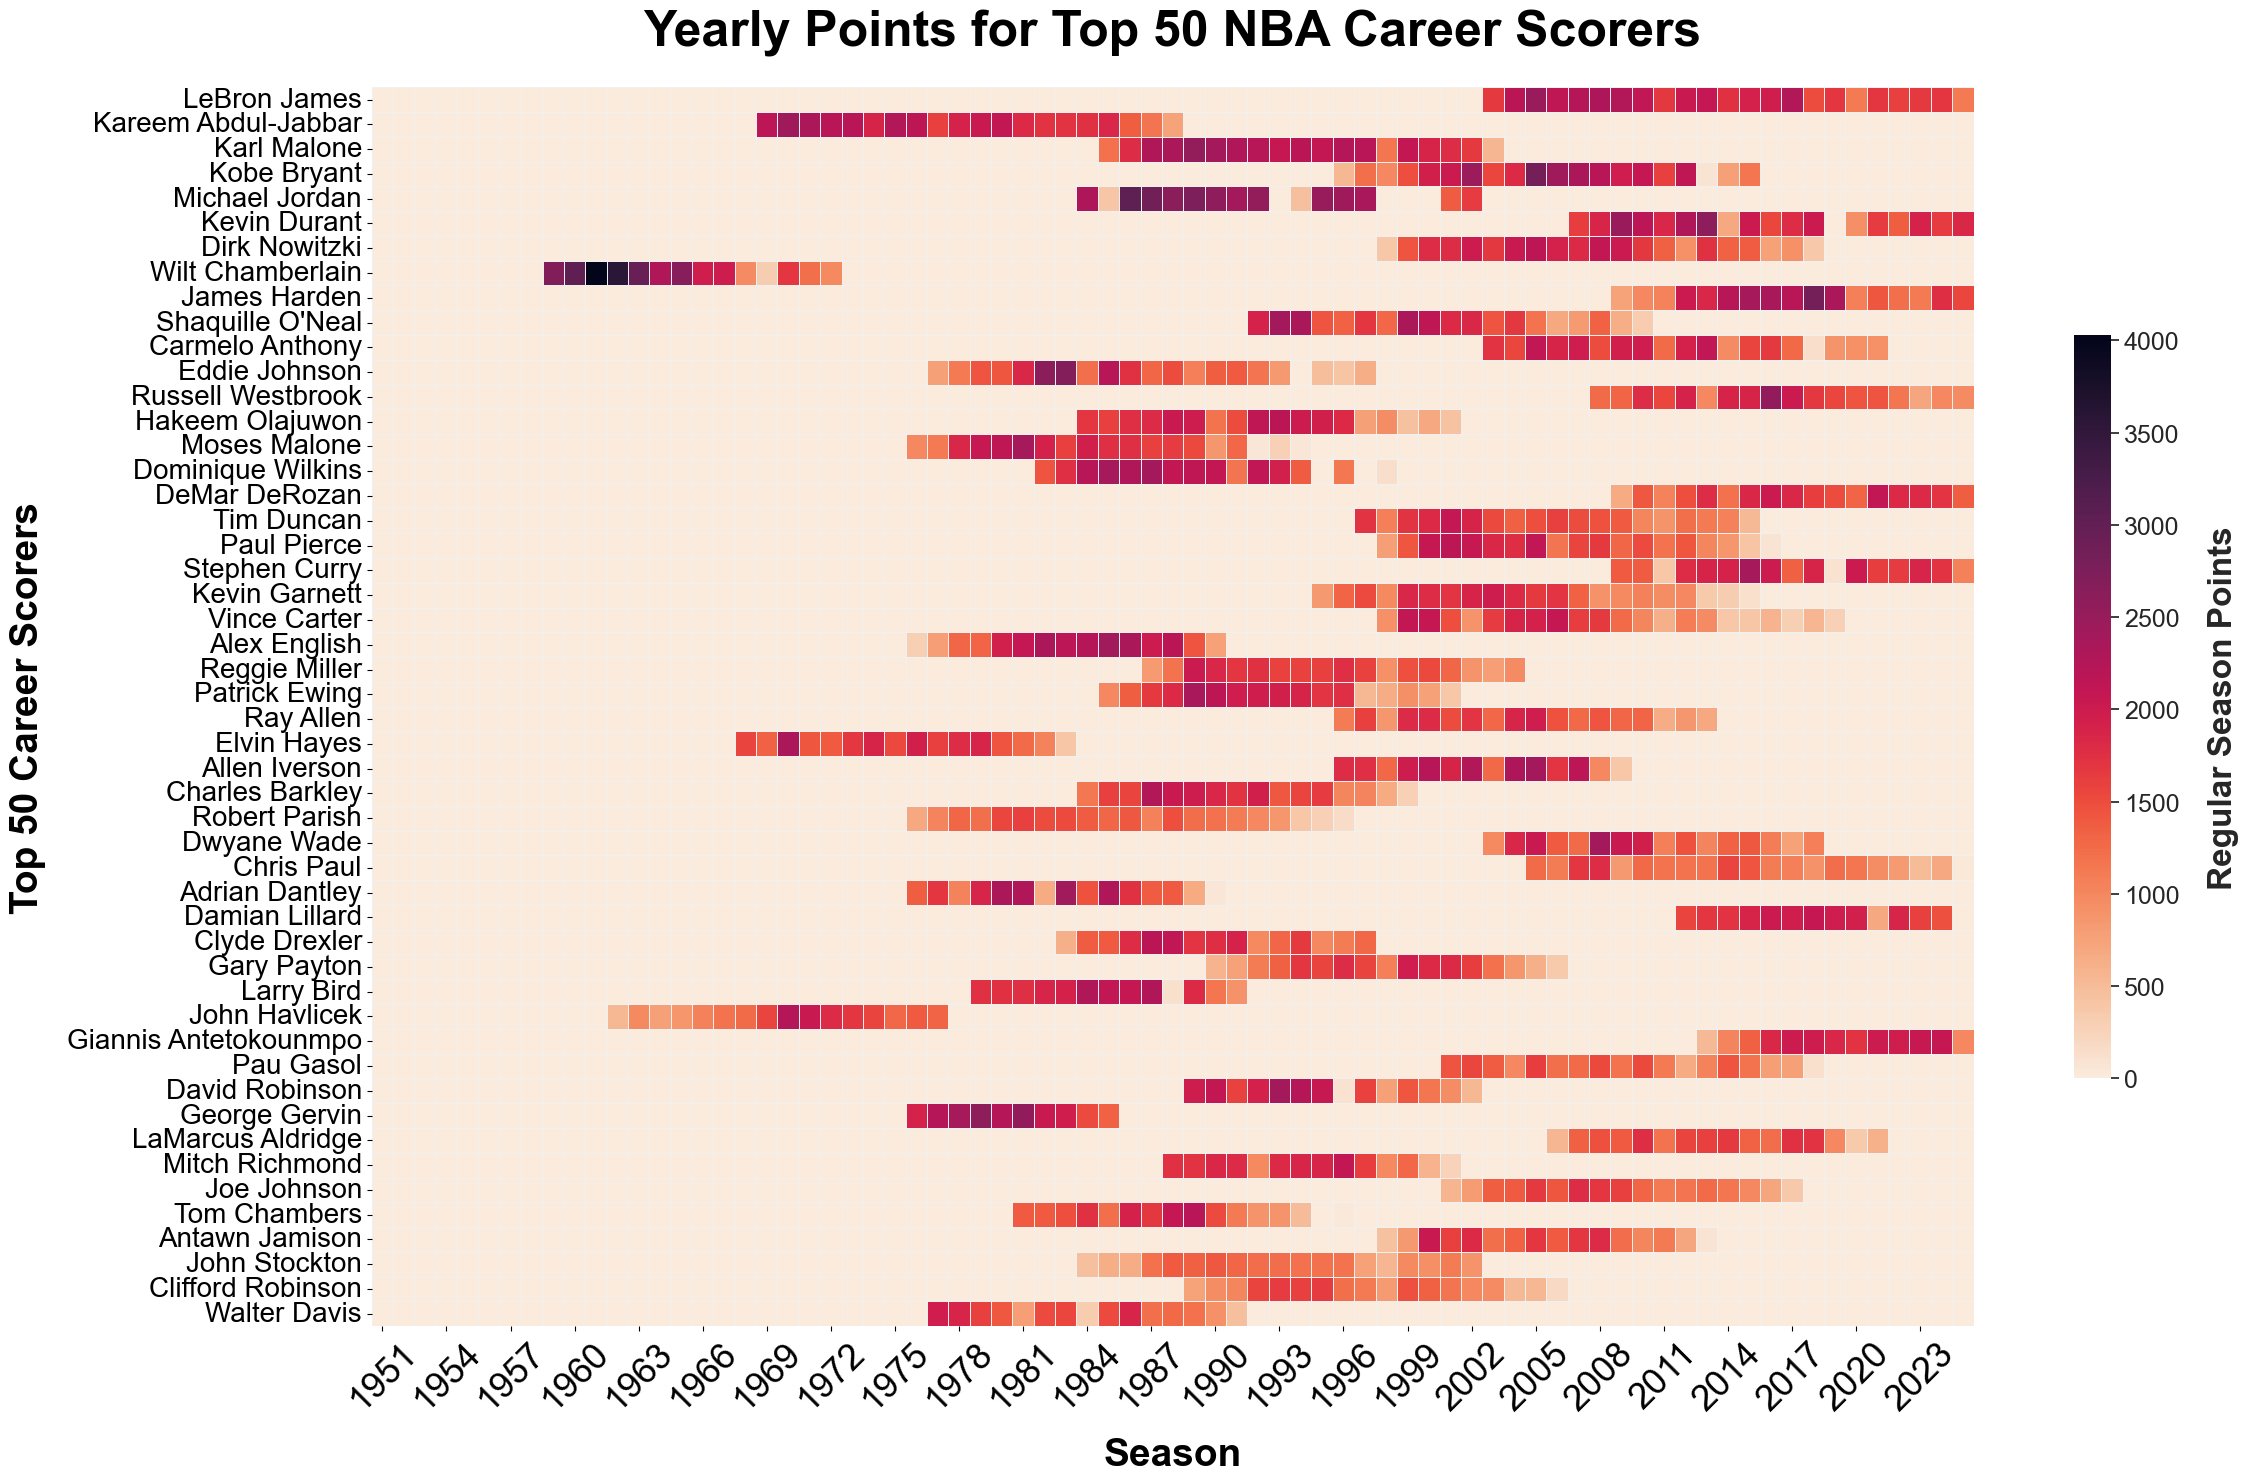

In [12]:
# Prepare player data
df_players = player_stats.copy()

df_players["points"] = pd.to_numeric(df_players["points"], errors="coerce").fillna(0)
# Ensure consistency: use numMinutes filter for clean game data
df_players["numMinutes"] = pd.to_numeric(df_players["numMinutes"], errors="coerce")
df_players = df_players[df_players["numMinutes"] > 0]

df_players = df_players[df_players["gameType"] == "Regular Season"]

df_players["year"] = df_players["gameDateTimeEst"].dt.year
df_players["season"] = df_players["year"]
# Jan-Aug belong to previous year's season start
mask_second_half = df_players["gameDateTimeEst"].dt.month < 9
df_players.loc[mask_second_half, "season"] = df_players.loc[mask_second_half, "year"] - 1

df_players["player_name"] = (df_players["firstName"] + " " + df_players["lastName"]).str.strip()

plot_heatmap(
    data=df_players,
    index_col="player_name",
    column_col="season",
    value_col="points",
    agg_func='sum',
    title="Yearly Points for Top 50 NBA Career Scorers",
    y_label="Top 50 Career Scorers",
    cbar_label="Regular Season Points",
    top_n=50
)

Max win: 73.0
Col value for max: Warriors


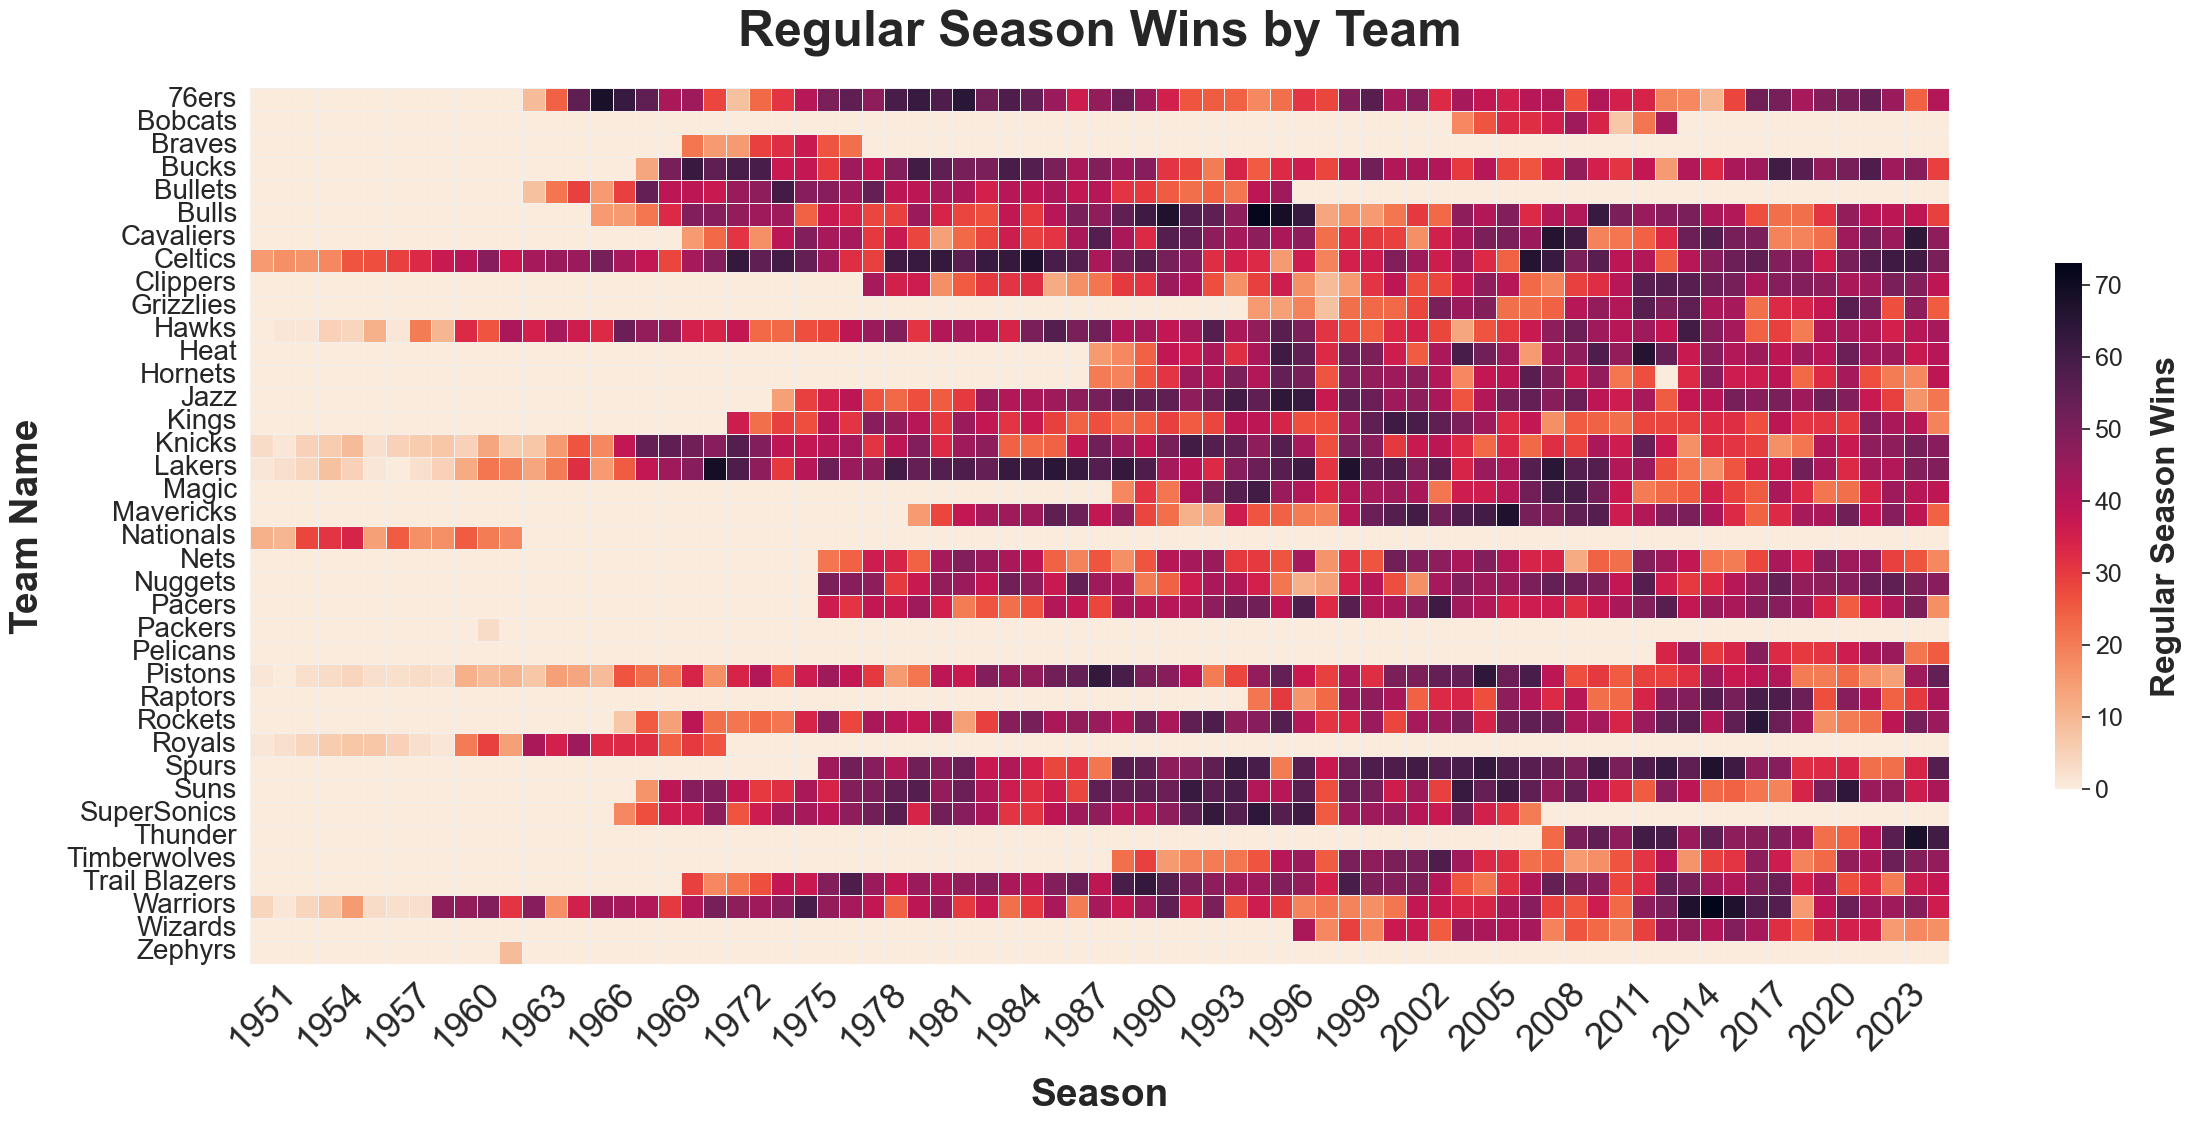

In [13]:
df_teams = pd.read_csv(DATA_PATH + "/nba_database/TeamStatistics.csv")

# filter for strictly regular season games from df_players gameId
df_teams = df_teams[df_teams["gameId"].isin(df_players["gameId"].unique())]

df_teams["gameDateTimeEst"] = pd.to_datetime(df_teams["gameDateTimeEst"])
df_teams["year"] = df_teams["gameDateTimeEst"].dt.year
df_teams["season"] = df_teams["year"]
mask_second_half = df_teams["gameDateTimeEst"].dt.month < 9
df_teams.loc[mask_second_half, "season"] = df_teams.loc[mask_second_half, "year"] - 1

plot_heatmap(
    data=df_teams,
    index_col="teamName",
    column_col="season",
    value_col="win",
    agg_func='sum',
    title="Regular Season Wins by Team",
    y_label="Team Name",
    cbar_label="Regular Season Wins"
)

## NBA Shot Details Dataset

This dataset (https://www.kaggle.com/datasets/brains14482/nba-playbyplay-and-shotdetails-data-19962021/data) is a large-scale play-by-play and shot-detail dataset covering both NBA and WNBA games, collected from multiple public sources (e.g., official league APIs and stats sites). It provides every in-game event—from period starts, jump balls, fouls, turnovers, rebounds, and field-goal attempts through free throws—along with detailed shot metadata (shot location, distance, result, assisting player, etc.).

For now the part that we are interested in are shot details data. Unfortunately, we get this information only starting from the 1996 season (year from NBA started tracking this data).

In [14]:
shotdetails = pd.read_csv(DATA_PATH + "/nba_play_by_play_shot_data/shotdetail_2015.csv")
shotdetails

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
0,Shot Chart Detail,21500001,6,200794,Paul Millsap,1610612737,Atlanta Hawks,1,11,0,...,Right Side(R),8-16 ft.,12,76,95,1,1,20151027,ATL,DET
1,Shot Chart Detail,21500001,8,201143,Al Horford,1610612737,Atlanta Hawks,1,10,27,...,Left Side Center(LC),16-24 ft.,20,-117,164,1,0,20151027,ATL,DET
2,Shot Chart Detail,21500001,13,200794,Paul Millsap,1610612737,Atlanta Hawks,1,10,1,...,Right Side(R),8-16 ft.,12,123,3,1,1,20151027,ATL,DET
3,Shot Chart Detail,21500001,20,201952,Jeff Teague,1610612737,Atlanta Hawks,1,9,29,...,Center(C),8-16 ft.,15,-2,154,1,0,20151027,ATL,DET
4,Shot Chart Detail,21500001,23,201952,Jeff Teague,1610612737,Atlanta Hawks,1,9,12,...,Center(C),Less Than 8 ft.,1,12,2,1,0,20151027,ATL,DET
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207888,Shot Chart Detail,21501221,557,1626162,Kelly Oubre Jr.,1610612764,Washington Wizards,4,3,50,...,Left Side(L),8-16 ft.,8,-86,21,1,0,20160413,WAS,ATL
207889,Shot Chart Detail,21501221,561,201196,Ramon Sessions,1610612764,Washington Wizards,4,3,31,...,Right Side Center(RC),24+ ft.,25,96,237,1,0,20160413,WAS,ATL
207890,Shot Chart Detail,21501221,563,204067,Jarell Eddie,1610612764,Washington Wizards,4,3,22,...,Center(C),Less Than 8 ft.,0,-4,7,1,0,20160413,WAS,ATL
207891,Shot Chart Detail,21501221,587,201162,Jared Dudley,1610612764,Washington Wizards,4,1,49,...,Left Side Center(LC),16-24 ft.,17,-104,139,1,1,20160413,WAS,ATL


In [15]:
shotdetails.columns

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM'],
      dtype='str')

In [16]:
shotdetails[["LOC_X", "LOC_Y"]].describe()

,LOC_X,LOC_Y
count,207893.000000,207893.000000
mean,-1.986286,81.347587
std,110.361773,89.182771
min,-250.000000,-51.000000
25%,-53.000000,7.000000
50%,0.000000,41.000000
75%,50.000000,156.000000
max,250.000000,856.000000


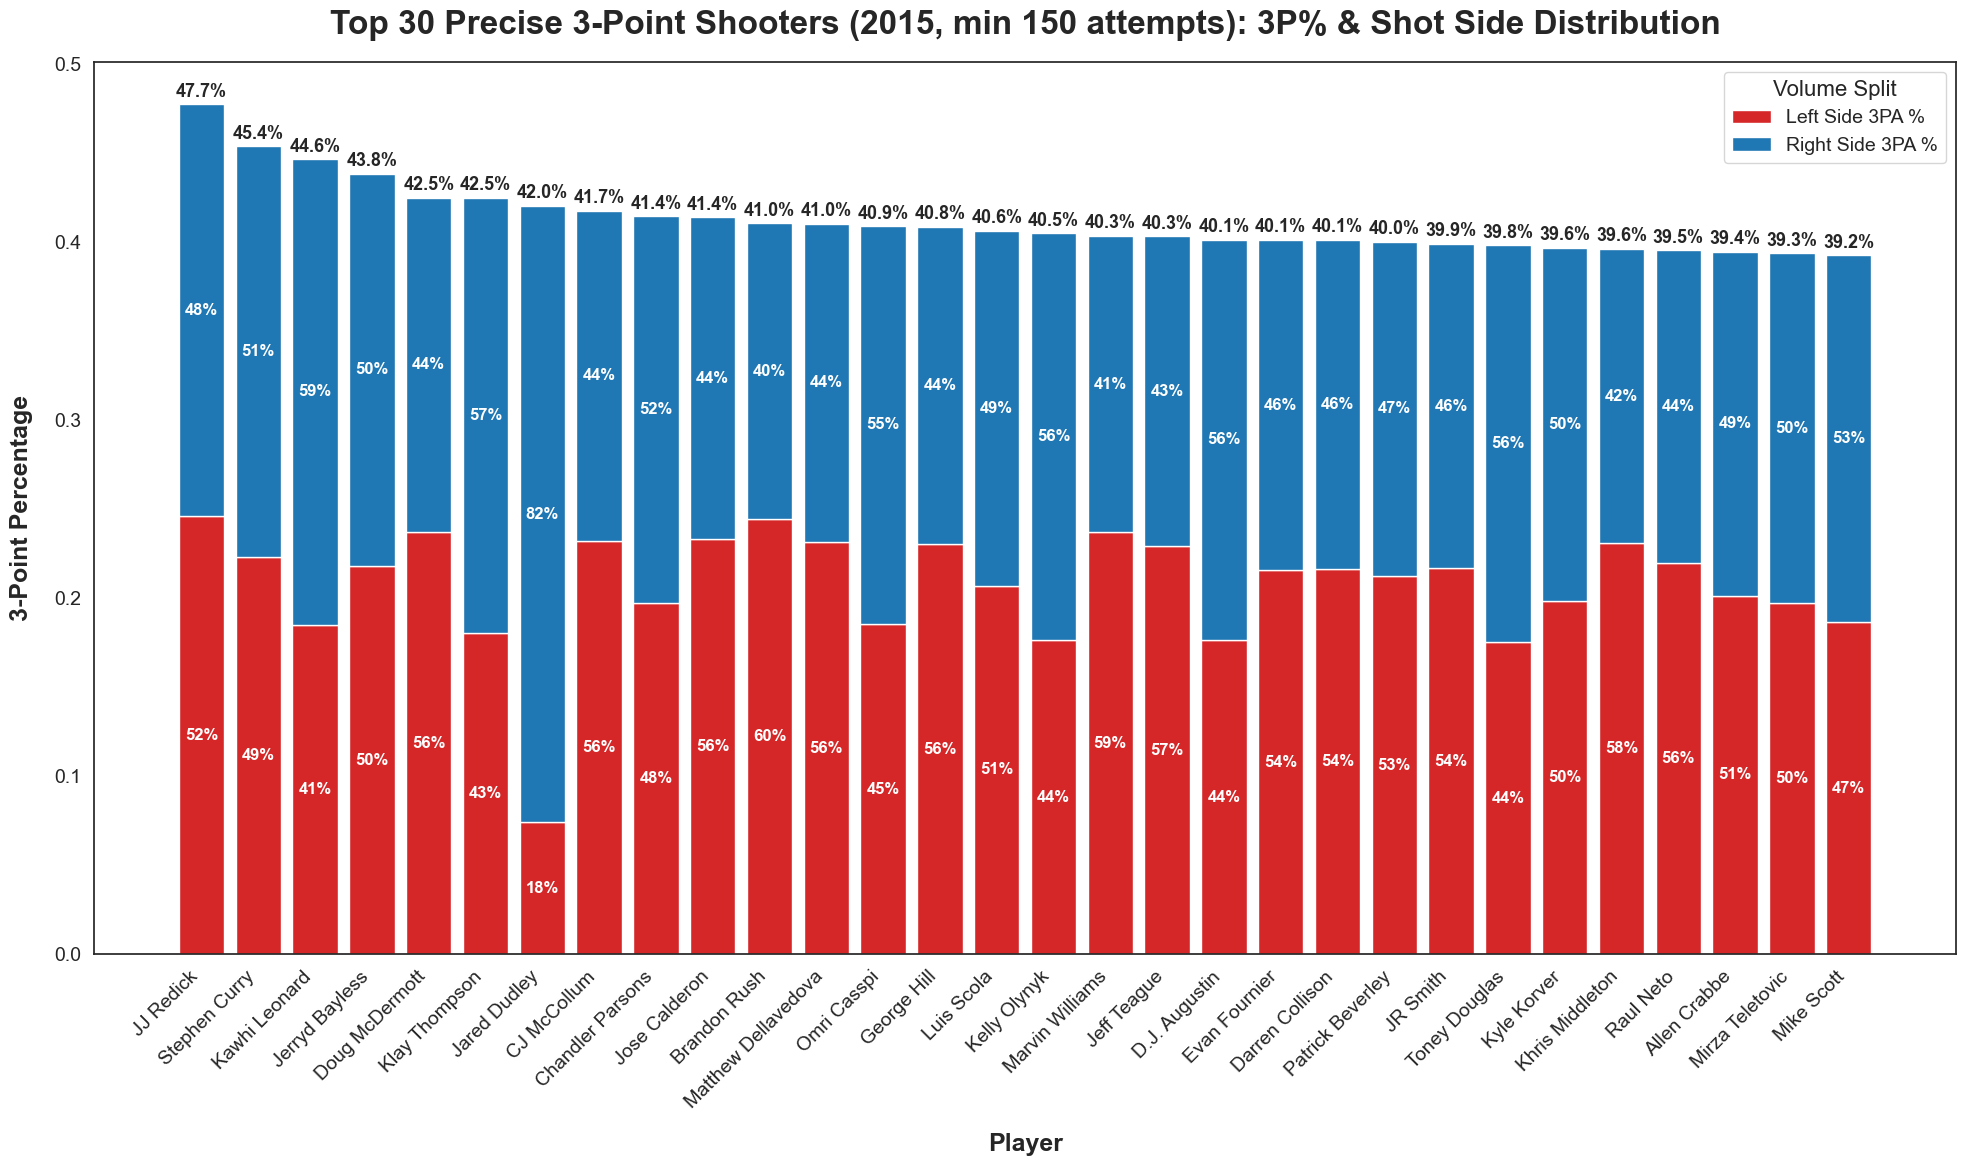

In [17]:
# filter for 3-Point Shots
three_point_shots = shotdetails[shotdetails['SHOT_TYPE'] == '3PT Field Goal'].copy()# Group by player to get total attempts and made shots
player_stats = three_point_shots.groupby('PLAYER_NAME').agg(
    total_attempts=('SHOT_ATTEMPTED_FLAG', 'count'),
    made_shots=('SHOT_MADE_FLAG', 'sum')
).reset_index()

# calculate accuracy
player_stats['FG_PCT'] = player_stats['made_shots'] / player_stats['total_attempts']

# Filter for meaningful players
qualified_players = player_stats[player_stats['total_attempts'] >= 150].copy()

# Get top 30 by Accuracy
top_players = qualified_players.sort_values('FG_PCT', ascending=False).head(30).reset_index(drop=True)

# calculate left/right Volume
def get_side_proportions(player_name):
    p_shots = three_point_shots[three_point_shots['PLAYER_NAME'] == player_name]
    
    # left (x < 0) and right (x > 0) shots
    left_vol = len(p_shots[p_shots['LOC_X'] < 0])
    right_vol = len(p_shots[p_shots['LOC_X'] > 0])
    
    total_side = left_vol + right_vol
    if total_side == 0: return pd.Series([0, 0], index=['Left_Pct', 'Right_Pct'])
    
    return pd.Series([left_vol / total_side, right_vol / total_side], index=['Left_Pct', 'Right_Pct'])

side_props = top_players['PLAYER_NAME'].apply(get_side_proportions)
plot_data = pd.concat([top_players, side_props], axis=1)
plot_data['PLAYER_NAME'] = plot_data['PLAYER_NAME'].astype(str)

# plotting
sns.set_context("notebook", font_scale=1.5)
plt.figure(figsize=(20, 12))

p1 = plt.bar(plot_data['PLAYER_NAME'], plot_data['FG_PCT'] * plot_data['Left_Pct'], color='#D62728', label='Left Side 3PA %')
p2 = plt.bar(plot_data['PLAYER_NAME'], plot_data['FG_PCT'] * plot_data['Right_Pct'], bottom=plot_data['FG_PCT'] * plot_data['Left_Pct'], color='#1F77B4', label='Right Side 3PA %')

# add values to the chart
for i, row in plot_data.iterrows():
    total_pct = row['FG_PCT']
    plt.text(i, total_pct + 0.002, f"{total_pct:.1%}", ha='center', va='bottom', fontsize=13, fontweight='bold', rotation=0)

    h_left = row['FG_PCT'] * row['Left_Pct']
    plt.text(i, h_left / 2, f"{row['Left_Pct']:.0%}", ha='center', va='center', color='white', fontsize=12, fontweight='bold')

    h_left = row['FG_PCT'] * row['Left_Pct']
    h_right = row['FG_PCT'] * row['Right_Pct']
    plt.text(i, h_left + h_right / 2, f"{row['Right_Pct']:.0%}", ha='center', va='center', color='white', fontsize=12, fontweight='bold')

plt.title('Top 30 Precise 3-Point Shooters (2015, min 150 attempts): 3P% & Shot Side Distribution', fontsize=24, fontweight='bold', pad=20)
plt.xlabel('Player', fontsize=18, fontweight='bold', labelpad=15)
plt.ylabel('3-Point Percentage', fontsize=18, fontweight='bold', labelpad=15)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right', title="Volume Split", fontsize=14, title_fontsize=16)

plt.tight_layout()
plt.show()

## NBA awards dataset exploration

This dataset (https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats) contains a lot of data about players / teams:

- All-Star Selections : all the players that have been selected for the All-Star game

- End of Season Teams : all the players that have been selected for the All-NBA teams, All-Defensive teams, and All-Rookie teams (best players of the seasons)

- Player Award Shares : all the players that have been selected for an award (MVP, ROY, DPOY, etc.) and the percentage of votes they received for that award.

- Some other datasets that we will not be using for our project since they overlap with the ones mentioned earlier (team statistics, players statistics...).

For now the part that we are interested in are the awards (MVP, ROY, DPOY, etc.). 

In [18]:
awards = pd.read_csv(DATA_PATH + "/nba_awards/Player Award Shares.csv")
awards.head()

,season,award,player,player_id,age,first,pts_won,pts_max,share,winner
0,2025,nba clutch_poy,Jalen Brunson,brunsja01,28,70.0,426.0,500.0,0.852,True
1,2025,nba clutch_poy,Nikola Jokić,jokicni01,29,26.0,312.0,500.0,0.624,False
2,2025,nba clutch_poy,Anthony Edwards,edwaran01,23,2.0,47.0,500.0,0.094,False
3,2025,nba clutch_poy,Trae Young,youngtr01,26,0.0,44.0,500.0,0.088,False
4,2025,nba clutch_poy,Stephen Curry,curryst01,36,1.0,27.0,500.0,0.054,False


In [19]:
awards.info()

<class 'pandas.DataFrame'>
RangeIndex: 3465 entries, 0 to 3464
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     3465 non-null   int64  
 1   award      3465 non-null   str    
 2   player     3465 non-null   str    
 3   player_id  3464 non-null   str    
 4   age        3465 non-null   int64  
 5   first      3426 non-null   float64
 6   pts_won    3442 non-null   float64
 7   pts_max    3442 non-null   float64
 8   share      3442 non-null   float64
 9   winner     3465 non-null   bool   
dtypes: bool(1), float64(4), int64(2), str(3)
memory usage: 247.1 KB


In [20]:
awards[["age", "pts_won", "pts_max", "share"]].describe()

,age,pts_won,pts_max,share
count,3465.000000,3442.000000,3442.000000,3442.000000
mean,26.129293,73.472952,561.011621,0.129200
std,3.855730,168.970197,341.615492,0.228257
min,19.000000,0.100000,17.000000,0.001000
25%,23.000000,2.000000,223.000000,0.006000
50%,26.000000,7.000000,600.000000,0.020000
75%,29.000000,46.000000,690.000000,0.128000
max,40.000000,1310.000000,1310.000000,1.000000


In [21]:
# Exemple if we need data of all MVP winners
awards = awards[(awards.winner == True) & (awards.award == "nba mvp")][["season", "player", "award", "share"]]
awards["percentage of votes received"] = awards["share"] * 100
awards.drop(columns=["share"], inplace=True)
awards.reset_index(drop=True, inplace=True)
awards

,season,player,award,percentage of votes received
0,2025,Shai Gilgeous-Alexander,nba mvp,91.3
1,2024,Nikola Jokić,nba mvp,93.5
2,2023,Joel Embiid,nba mvp,91.5
3,2022,Nikola Jokić,nba mvp,87.5
4,2021,Nikola Jokić,nba mvp,96.1
...,...,...,...,...
65,1960,Wilt Chamberlain,nba mvp,68.4
66,1959,Bob Pettit,nba mvp,77.3
67,1958,Bill Russell,nba mvp,57.0
68,1957,Bob Cousy,nba mvp,28.8


In [22]:
all_stars = pd.read_csv(DATA_PATH + "/nba_awards/All-Star Selections.csv")
all_stars

,player,player_id,team,season,lg,replaced
0,Scottie Barnes,barnesc01,Team Stars,2026,NBA,False
1,Devin Booker,bookede01,Team Stars,2026,NBA,False
2,Cade Cunningham,cunnica01,Team Stars,2026,NBA,False
3,Jalen Duren,durenja01,Team Stars,2026,NBA,False
4,Anthony Edwards,edwaran01,Team Stars,2026,NBA,False
...,...,...,...,...,...,...
2053,Alex Groza,grozaal01,West,1951,NBA,False
2054,George Mikan,mikange01,West,1951,NBA,False
2055,Vern Mikkelsen,mikkeve01,West,1951,NBA,False
2056,Jim Pollard,pollaji01,West,1951,NBA,False


In [23]:
all_teams = pd.read_csv(DATA_PATH + "/nba_awards/End of Season Teams.csv")
all_teams

,season,lg,type,number_tm,player,player_id,position
0,2025,NBA,All-Defense,1st,Dyson Daniels,daniedy01,NaN
1,2025,NBA,All-Defense,1st,Luguentz Dort,dortlu01,NaN
2,2025,NBA,All-Defense,1st,Draymond Green,greendr01,NaN
3,2025,NBA,All-Defense,1st,Evan Mobley,mobleev01,NaN
4,2025,NBA,All-Defense,1st,Amen Thompson,thompam01,NaN
...,...,...,...,...,...,...,...
2217,1947,BAA,All-BAA,2nd,Frankie Baumholtz,baumhfr01,NaN
2218,1947,BAA,All-BAA,2nd,Ernie Calverley,calveer01,NaN
2219,1947,BAA,All-BAA,2nd,Chick Halbert,halbech01,NaN
2220,1947,BAA,All-BAA,2nd,John Logan,loganjo01,NaN
